# Hospital Patient Care Analytics Pipeline

## Data Engineering Case Study
> By : Yaswanth kumar reddy

**Objective:** Build a simple end-to-end data engineering pipeline for a multi-specialty hospital.

The hospital receives information from different systems such as patient registration, appointments, laboratory reports, wearable devices, and doctor consultation notes. The goal of this project is to combine these sources, clean the data, generate useful insights, and identify patients who may need additional attention.

> This notebook uses **synthetic data** for demonstration. It does not contain real patient information.


## 1. Problem Understanding

The hospital wants to improve its daily operations and patient outcomes. A single department may have information about appointments, while another system stores lab results or wearable-device readings.

If these sources are not combined properly, it becomes difficult to answer questions such as:

- Which departments have longer waiting times?
- How many appointments are completed, cancelled, or missed?
- Which patients have abnormal health readings?
- Which patients may require follow-up?
- What operational changes can reduce delays?

### Proposed pipeline

1. Collect data from different hospital systems.
2. Store the raw data.
3. Clean and standardize the data.
4. Combine the datasets using patient and appointment identifiers.
5. Perform exploratory analysis.
6. Generate operational and patient-risk insights.
7. Store the processed output for reporting.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries imported successfully")


Libraries imported successfully


## 2. Creating Sample Source Data

For this case study, I am creating small sample datasets to represent the different systems used by a hospital.

The datasets are:

- **Patients:** Basic registration information.
- **Appointments:** Appointment scheduling and waiting time.
- **Laboratory reports:** Basic test results.
- **Wearable readings:** Heart rate, oxygen saturation, and temperature.
- **Consultations:** Doctor observations and consultation outcomes.

In a real project, these records could come from hospital databases, APIs, CSV files, or streaming systems.


In [2]:
# Patient registration data
patients = pd.DataFrame({
    "patient_id": [101, 102, 103, 104, 105, 106, 107, 108],
    "age": [25, 67, 45, 72, 34, 59, 81, 40],
    "gender": ["F", "M", "F", "M", "F", "M", "F", "M"],
    "department": [
        "General", "Cardiology", "General", "Emergency",
        "Orthopedics", "Cardiology", "Emergency", "General"
    ]
})

patients


,patient_id,age,gender,department
0,101,25,F,General
1,102,67,M,Cardiology
2,103,45,F,General
3,104,72,M,Emergency
4,105,34,F,Orthopedics
5,106,59,M,Cardiology
6,107,81,F,Emergency
7,108,40,M,General


In [3]:
# Appointment scheduling data
appointments = pd.DataFrame({
    "appointment_id": [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008],
    "patient_id": [101, 102, 103, 104, 105, 106, 107, 108],
    "appointment_status": [
        "Completed", "Completed", "Cancelled", "Completed",
        "Completed", "No Show", "Completed", "Completed"
    ],
    "waiting_time_min": [25, 65, 15, 95, 40, 50, 120, 35],
    "doctor_consultation_min": [15, 30, 10, 35, 20, 25, 45, 20]
})

appointments


,appointment_id,patient_id,appointment_status,waiting_time_min,doctor_consultation_min
0,2001,101,Completed,25,15
1,2002,102,Completed,65,30
2,2003,103,Cancelled,15,10
3,2004,104,Completed,95,35
4,2005,105,Completed,40,20
5,2006,106,No Show,50,25
6,2007,107,Completed,120,45
7,2008,108,Completed,35,20


In [4]:
# Laboratory report data
lab_reports = pd.DataFrame({
    "patient_id": [101, 102, 103, 104, 105, 106, 107, 108],
    "hemoglobin": [13.5, 11.2, 12.8, 10.1, 13.1, 12.0, 9.8, 14.0],
    "glucose": [95, 145, 110, 180, 100, 160, 190, 105],
    "test_status": ["Normal", "Review", "Normal", "Review",
                    "Normal", "Review", "Review", "Normal"]
})

lab_reports


,patient_id,hemoglobin,glucose,test_status
0,101,13.5,95,Normal
1,102,11.2,145,Review
2,103,12.8,110,Normal
3,104,10.1,180,Review
4,105,13.1,100,Normal
5,106,12.0,160,Review
6,107,9.8,190,Review
7,108,14.0,105,Normal


In [5]:
# Wearable-device readings
wearable_data = pd.DataFrame({
    "patient_id": [101, 102, 103, 104, 105, 106, 107, 108],
    "heart_rate": [76, 98, 82, 112, 79, 105, 118, 80],
    "oxygen_saturation": [98, 95, 97, 92, 99, 94, 90, 98],
    "temperature": [36.7, 37.2, 36.8, 38.1, 36.6, 37.5, 38.4, 36.9]
})

wearable_data


,patient_id,heart_rate,oxygen_saturation,temperature
0,101,76,98,36.7
1,102,98,95,37.2
2,103,82,97,36.8
3,104,112,92,38.1
4,105,79,99,36.6
5,106,105,94,37.5
6,107,118,90,38.4
7,108,80,98,36.9


In [6]:
# Consultation notes represented as structured fields
consultations = pd.DataFrame({
    "patient_id": [101, 102, 103, 104, 105, 106, 107, 108],
    "follow_up_required": ["No", "Yes", "No", "Yes", "No", "Yes", "Yes", "No"],
    "consultation_priority": ["Routine", "Medium", "Routine", "High",
                              "Routine", "Medium", "High", "Routine"]
})

consultations


,patient_id,follow_up_required,consultation_priority
0,101,No,Routine
1,102,Yes,Medium
2,103,No,Routine
3,104,Yes,High
4,105,No,Routine
5,106,Yes,Medium
6,107,Yes,High
7,108,No,Routine


## 3. Basic Data Quality Checks

Before joining the datasets, I checked the structure of the data. In a real hospital pipeline, this step is important because missing identifiers, duplicate records, or invalid values can affect the final analysis.


In [7]:
def basic_quality_check(dataframe, name):
    print(f"\n{name}")
    print("-" * len(name))
    print("Rows:", len(dataframe))
    print("Columns:", len(dataframe.columns))
    print("Missing values:")
    print(dataframe.isnull().sum())
    print("Duplicate rows:", dataframe.duplicated().sum())

basic_quality_check(patients, "Patients")
basic_quality_check(appointments, "Appointments")
basic_quality_check(lab_reports, "Laboratory Reports")
basic_quality_check(wearable_data, "Wearable Data")
basic_quality_check(consultations, "Consultations")



Patients
--------
Rows: 8
Columns: 4
Missing values:
patient_id    0
age           0
gender        0
department    0
dtype: int64
Duplicate rows: 0

Appointments
------------
Rows: 8
Columns: 5
Missing values:
appointment_id             0
patient_id                 0
appointment_status         0
waiting_time_min           0
doctor_consultation_min    0
dtype: int64
Duplicate rows: 0

Laboratory Reports
------------------
Rows: 8
Columns: 4
Missing values:
patient_id     0
hemoglobin     0
glucose        0
test_status    0
dtype: int64
Duplicate rows: 0

Wearable Data
-------------
Rows: 8
Columns: 4
Missing values:
patient_id           0
heart_rate           0
oxygen_saturation    0
temperature          0
dtype: int64
Duplicate rows: 0

Consultations
-------------
Rows: 8
Columns: 3
Missing values:
patient_id               0
follow_up_required       0
consultation_priority    0
dtype: int64
Duplicate rows: 0


## 4. Data Cleaning and Transformation

The next step is to prepare the data for analysis.

The transformations used here are simple:

- Remove duplicate rows.
- Standardize text values.
- Check for missing values.
- Make sure numerical columns contain numeric values.
- Keep identifiers consistent across all datasets.

For a production system, additional validation would be required, including timestamp checks, range validation, data lineage, and handling late-arriving records.


In [8]:
# Create copies so the original source data remains unchanged
patients_clean = patients.copy()
appointments_clean = appointments.copy()
lab_clean = lab_reports.copy()
wearable_clean = wearable_data.copy()
consultations_clean = consultations.copy()

# Remove duplicate rows
patients_clean = patients_clean.drop_duplicates()
appointments_clean = appointments_clean.drop_duplicates()
lab_clean = lab_clean.drop_duplicates()
wearable_clean = wearable_clean.drop_duplicates()
consultations_clean = consultations_clean.drop_duplicates()

# Standardize text columns
patients_clean["gender"] = patients_clean["gender"].str.upper()
patients_clean["department"] = patients_clean["department"].str.strip().str.title()
appointments_clean["appointment_status"] = (
    appointments_clean["appointment_status"].str.strip().str.title()
)
lab_clean["test_status"] = lab_clean["test_status"].str.strip().str.title()

# Convert numerical columns explicitly
appointments_clean["waiting_time_min"] = pd.to_numeric(
    appointments_clean["waiting_time_min"], errors="coerce"
)
wearable_clean["oxygen_saturation"] = pd.to_numeric(
    wearable_clean["oxygen_saturation"], errors="coerce"
)

print("Cleaning and standardization completed")


Cleaning and standardization completed


## 5. Combining the Data

The patient ID is used as the common key between the different datasets.

I first combine the patient registration data with appointment data. Then I add laboratory results, wearable readings, and consultation information.

This produces a single analytical dataset that can be used for reporting and further processing.


In [9]:
hospital_data = patients_clean.merge(
    appointments_clean,
    on="patient_id",
    how="left"
)

hospital_data = hospital_data.merge(
    lab_clean,
    on="patient_id",
    how="left"
)

hospital_data = hospital_data.merge(
    wearable_clean,
    on="patient_id",
    how="left"
)

hospital_data = hospital_data.merge(
    consultations_clean,
    on="patient_id",
    how="left"
)

hospital_data


,patient_id,age,gender,department,appointment_id,appointment_status,waiting_time_min,doctor_consultation_min,hemoglobin,glucose,test_status,heart_rate,oxygen_saturation,temperature,follow_up_required,consultation_priority
0,101,25,F,General,2001,Completed,25,15,13.5,95,Normal,76,98,36.7,No,Routine
1,102,67,M,Cardiology,2002,Completed,65,30,11.2,145,Review,98,95,37.2,Yes,Medium
2,103,45,F,General,2003,Cancelled,15,10,12.8,110,Normal,82,97,36.8,No,Routine
3,104,72,M,Emergency,2004,Completed,95,35,10.1,180,Review,112,92,38.1,Yes,High
4,105,34,F,Orthopedics,2005,Completed,40,20,13.1,100,Normal,79,99,36.6,No,Routine
5,106,59,M,Cardiology,2006,No Show,50,25,12.0,160,Review,105,94,37.5,Yes,Medium
6,107,81,F,Emergency,2007,Completed,120,45,9.8,190,Review,118,90,38.4,Yes,High
7,108,40,M,General,2008,Completed,35,20,14.0,105,Normal,80,98,36.9,No,Routine


In [10]:
print("Final dataset shape:", hospital_data.shape)
print("\nMissing values in the combined dataset:")
print(hospital_data.isnull().sum())


Final dataset shape: (8, 16)

Missing values in the combined dataset:
patient_id                 0
age                        0
gender                     0
department                 0
appointment_id             0
appointment_status         0
waiting_time_min           0
doctor_consultation_min    0
hemoglobin                 0
glucose                    0
test_status                0
heart_rate                 0
oxygen_saturation          0
temperature                0
follow_up_required         0
consultation_priority      0
dtype: int64


## 6. Operational Analysis

One of the hospital's main goals is to reduce patient waiting time.

I grouped the records by department and calculated the average waiting time. This helps management understand where delays may be occurring.

The sample is small, so the results should be treated as an illustration rather than a real hospital performance report.


In [11]:
department_waiting = (
    hospital_data.groupby("department")["waiting_time_min"]
    .mean()
    .sort_values(ascending=False)
)

department_waiting


department
Emergency      107.5
Cardiology      57.5
Orthopedics     40.0
General         25.0
Name: waiting_time_min, dtype: float64

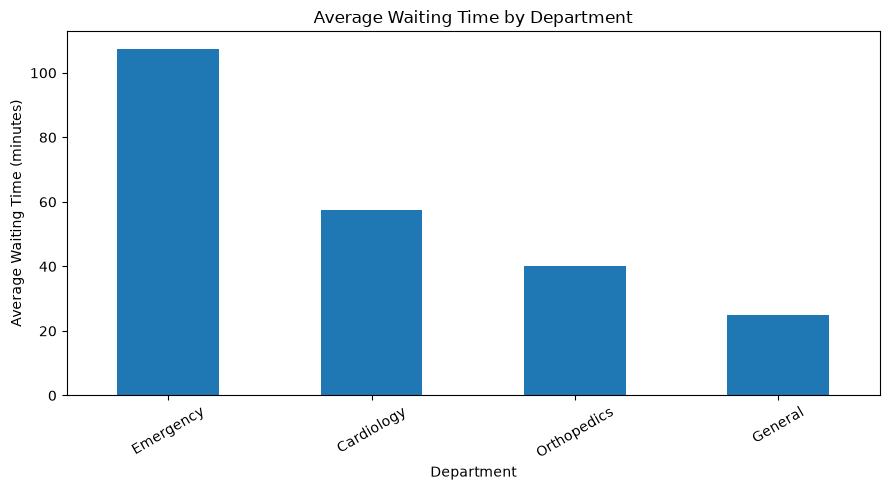

In [12]:
plt.figure(figsize=(9, 5))
department_waiting.plot(kind="bar")
plt.title("Average Waiting Time by Department")
plt.xlabel("Department")
plt.ylabel("Average Waiting Time (minutes)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Appointment status summary

The hospital can also check how many appointments were completed, cancelled, or missed. This information can support better scheduling and patient communication.


appointment_status
Completed    6
Cancelled    1
No Show      1
Name: count, dtype: int64


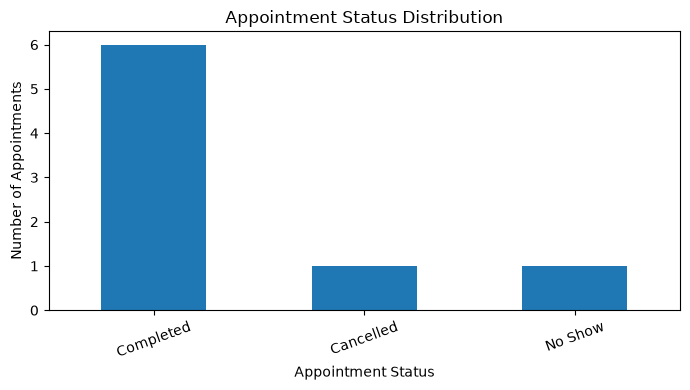

In [13]:
status_counts = hospital_data["appointment_status"].value_counts()

print(status_counts)

plt.figure(figsize=(7, 4))
status_counts.plot(kind="bar")
plt.title("Appointment Status Distribution")
plt.xlabel("Appointment Status")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 7. Identifying Potentially High-Risk Patients

The case study mentions predicting high-risk patients. A real prediction system would require a clinically validated model, historical patient records, medical review, and careful evaluation.

For this demonstration, I am using a **simple rule-based screening score**, not a medical diagnosis. The score is created only to show how data engineering outputs can be transformed into a screening dataset.

The following indicators add points:

- High heart rate.
- Low oxygen saturation.
- High temperature.
- High glucose.
- Low hemoglobin.
- A high consultation priority.
- A long waiting time.

The thresholds are illustrative and must not be used for real clinical decisions.


In [14]:
risk_data = hospital_data.copy()

risk_data["risk_score"] = 0

risk_data["risk_score"] += (risk_data["heart_rate"] > 100).astype(int)
risk_data["risk_score"] += (risk_data["oxygen_saturation"] < 95).astype(int)
risk_data["risk_score"] += (risk_data["temperature"] > 38).astype(int)
risk_data["risk_score"] += (risk_data["glucose"] > 140).astype(int)
risk_data["risk_score"] += (risk_data["hemoglobin"] < 11).astype(int)
risk_data["risk_score"] += (
    risk_data["consultation_priority"] == "High"
).astype(int)
risk_data["risk_score"] += (
    risk_data["waiting_time_min"] > 90
).astype(int)

risk_data["risk_category"] = pd.cut(
    risk_data["risk_score"],
    bins=[-1, 1, 3, 7],
    labels=["Low", "Medium", "High"]
)

risk_data[
    [
        "patient_id", "department", "risk_score",
        "risk_category", "follow_up_required"
    ]
].sort_values("risk_score", ascending=False)


,patient_id,department,risk_score,risk_category,follow_up_required
3,104,Emergency,7,High,Yes
6,107,Emergency,7,High,Yes
5,106,Cardiology,3,Medium,Yes
1,102,Cardiology,1,Low,Yes
2,103,General,0,Low,No
0,101,General,0,Low,No
4,105,Orthopedics,0,Low,No
7,108,General,0,Low,No


risk_category
Low       5
Medium    1
High      2
Name: count, dtype: int64


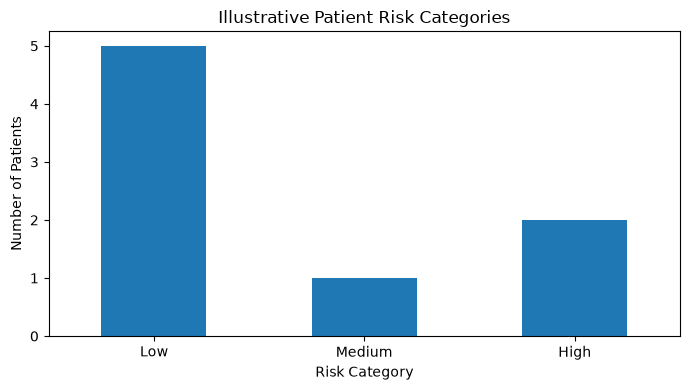

In [15]:
risk_summary = risk_data["risk_category"].value_counts().sort_index()

print(risk_summary)

plt.figure(figsize=(7, 4))
risk_summary.plot(kind="bar")
plt.title("Illustrative Patient Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Creating an Analytics Output Table

In a real data engineering architecture, the cleaned and enriched data could be written to a data warehouse or analytics database.

Here, I create a smaller output table containing the fields that might be useful for a hospital dashboard.


In [16]:
analytics_output = risk_data[
    [
        "patient_id", "department", "appointment_status",
        "waiting_time_min", "risk_score", "risk_category",
        "follow_up_required"
    ]
].copy()

analytics_output


,patient_id,department,appointment_status,waiting_time_min,risk_score,risk_category,follow_up_required
0,101,General,Completed,25,0,Low,No
1,102,Cardiology,Completed,65,1,Low,Yes
2,103,General,Cancelled,15,0,Low,No
3,104,Emergency,Completed,95,7,High,Yes
4,105,Orthopedics,Completed,40,0,Low,No
5,106,Cardiology,No Show,50,3,Medium,Yes
6,107,Emergency,Completed,120,7,High,Yes
7,108,General,Completed,35,0,Low,No


In [17]:
# Save the processed analytical output as a CSV file
output_file = "hospital_patient_analytics_output.csv"
analytics_output.to_csv(output_file, index=False)

print(f"Processed data saved to: {output_file}")


Processed data saved to: hospital_patient_analytics_output.csv


## 9. Suggested End-to-End Architecture

The Python workflow above represents the processing and analysis portion of the pipeline. A production-level solution could be designed as follows:

### Data sources

- Patient registration system
- Appointment scheduling system
- Laboratory information system
- Wearable health devices
- Doctor consultation system

### Ingestion layer

Data can be collected using APIs, scheduled batch jobs, message queues, or secure file transfers.

### Storage layer

- Raw zone: Keep the original source records.
- Cleaned zone: Store validated and standardized records.
- Curated zone: Store joined data prepared for analytics.

### Processing layer

A processing engine such as Apache Spark could be used for large datasets. Smaller workloads can be handled using Python and SQL-based processing.

### Analytics layer

The final data can be connected to dashboards for:

- Waiting-time analysis
- Appointment performance
- Department-level workload
- Laboratory trends
- Patient follow-up screening

### Governance and security

Because hospital data is sensitive, the system should include:

- Role-based access control
- Encryption in transit and at rest
- Audit logs
- Data minimization
- De-identification for analytics where appropriate
- Retention and backup policies


## 10. Final Observations

From this sample pipeline, the hospital can begin to understand its operational and patient-related data in one place.

The main outcomes of the project are:

1. Data from multiple hospital systems was combined using a common patient identifier.
2. Basic data cleaning and quality checks were performed.
3. Waiting times were analyzed department-wise.
4. Appointment statuses were summarized.
5. A simple illustrative risk-screening score was generated.
6. A processed CSV file was created for further reporting.

### Limitations

This notebook uses a small, synthetic dataset. It does not represent actual clinical prediction, and the risk score is not validated for medical use. A real implementation would need more historical data, clinical validation, monitoring, privacy controls, and a production data platform.
